In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

video_dirs = {
    "train_val": fr"D:\VATEX_ne\videos_train_val",
    "test": fr"D:\VATEX_ne\videos_test"
}

data = []

for split_name, video_dir in video_dirs.items():
    for filename in os.listdir(video_dir):
        if filename.endswith(".mp4"):
            video_path = os.path.join(video_dir, filename)
            cap = cv2.VideoCapture(video_path)

            if not cap.isOpened():
                print(f"Could not open {video_path}")
                continue

            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)

            if fps is None or fps <= 0:
                print(f"Invalid FPS for {video_path}")
                cap.release()
                continue

            duration = frame_count / fps

            data.append({
                "split": split_name,
                "video_name": filename,
                "fps": fps,
                "frame_count": frame_count,
                "duration_sec": duration
            })

            cap.release()

df = pd.DataFrame(data)

print(df.head())
print(df.groupby("split")["duration_sec"].describe())

       split       video_name       fps  frame_count  duration_sec
0  train_val  --07WQ2iBlw.mp4  29.97003        274.0      9.142467
1  train_val  --33Lscn6sk.mp4  30.00000        192.0      6.400000
2  train_val  --7goKgS4kc.mp4  30.00000        300.0     10.000000
3  train_val  --7VUM9MKg4.mp4  15.00000        118.0      7.866667
4  train_val  --8FQVwWH0M.mp4  30.00000        300.0     10.000000
             count      mean       std       min   25%   50%    75%        max
split                                                                         
test        5150.0  9.726286  1.048105  0.708333  10.0  10.0  10.01  10.120976
train_val  23871.0  9.632548  1.211665  0.533333  10.0  10.0  10.01  10.123809


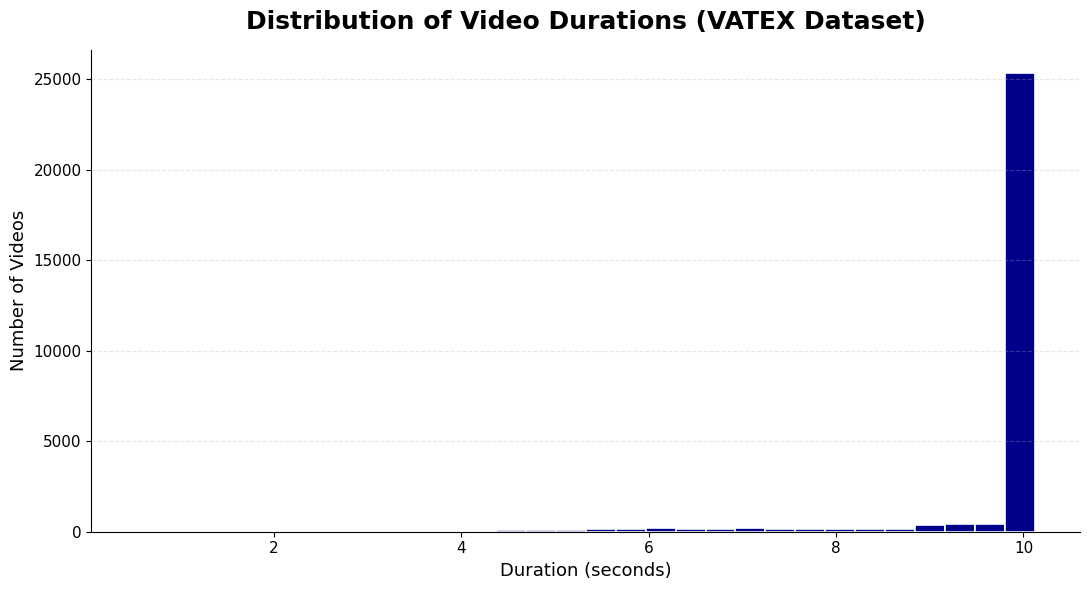

In [2]:
plt.figure(figsize=(11, 6))
plt.hist(
    df["duration_sec"],
    bins=30,
    edgecolor="white",
    linewidth=1.2,
    color = "darkblue"
)

plt.title("Distribution of Video Durations (VATEX Dataset)", fontsize=18, pad=15, weight="bold")
plt.xlabel("Duration (seconds)", fontsize=13)
plt.ylabel("Number of Videos", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_linewidth(0.8)
plt.gca().spines["bottom"].set_linewidth(0.8)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.style.use("ggplot")
plt.show()